# Análisis Exploratorio de Datos - Sentinel-2 L2A
## Proyecto Integrador - Maestría en IA Aplicada

**Dataset**: Sentinel-2 L2A (B01..B12)
**Fuente**: https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/examples/

**Autores**: 
* Carlos Isaac Ávila Gutiérrez: A01796035
* Carlos Aaron Bocanegra Buitrón: A01796345
* Arthur Jafed Zizumbo Velasco: A01796363

**Fecha**: 12 de Mayo del 2026


---

## Tabla de Contenidos
1. [Carga y Exploración Inicial](#1-carga)
2. [Análisis de Estructura del Dataset](#2-estructura)
3. [Análisis Univariante](#3-univariante)
4. [Análisis Temporal](#4-temporal)
5. [Análisis Bivariante/Multivariante](#6-bivariante)
6. [Detección de Valores Atípicos](#7-outliers)
7. [Preprocesamiento Recomendado](#8-preprocessing)
8. [Conclusiones del EDA](#9-conclusiones)

---

In [56]:
import os
import json
import io
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tifffile
import requests
from dotenv import load_dotenv
from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session
from scipy.stats import skew, kurtosis

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [57]:
load_dotenv('../../../.env.local')

sentinelhub_client_id = os.getenv('SENTINELHUB_CLIENT_ID')
sentinelhub_client_secret = os.getenv('SENTINELHUB_CLIENT_SECRET')

if not sentinelhub_client_id or not sentinelhub_client_secret:
    raise ValueError(
        'Set SENTINELHUB_CLIENT_ID and SENTINELHUB_CLIENT_SECRET in .env.local before running this notebook.'
    )

client = BackendApplicationClient(client_id=sentinelhub_client_id)
oauth = OAuth2Session(client=client)

token = oauth.fetch_token(
    token_url='https://services.sentinel-hub.com/auth/realms/main/protocol/openid-connect/token',
    client_id=sentinelhub_client_id,
    client_secret=sentinelhub_client_secret,
    include_client_id=True,
)

print('Sentinel Hub auth token acquired. Expires in', token.get('expires_in'), 'seconds.')


Sentinel Hub auth token acquired. Expires in 3600 seconds.


In [58]:
# Area of Interest (AOI) bounding box
# Format: [min_lon, min_lat, max_lon, max_lat]
# This example uses a small area in Iowa, USA. Adjust the coordinates as needed.
AOI_BBOX = [-94.06, 41.79, -94.04, 41.81]

In [59]:
def get_sentinel_data(bbox, date_from, date_to):
    url = 'https://services.sentinel-hub.com/api/v1/process'
    headers = {
        'Authorization': f"Bearer {token['access_token']}",
        'Content-Type': 'application/json',
    }

    evalscript = '''
    //VERSION=3
    function setup() {
      return {
        input: [{bands: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"], units: "DN"}],
        output: {id: 'default', bands: 12, sampleType: SampleType.UINT16}
      };
    }

    function evaluatePixel(sample) {
      return [ sample.B01, sample.B02, sample.B03, sample.B04, sample.B05, sample.B06, sample.B07, sample.B08, sample.B8A, sample.B09, sample.B11, sample.B12 ];
    }
    '''

    payload = {
        'input': {
            'bounds': {'bbox': bbox},
            'data': [{
                'type': 'sentinel-2-l2a',
                'dataFilter': {'timeRange': {'from': date_from, 'to': date_to}},
            }],
        },
        'output': {
            'width': 128,
            'height': 128,
            'responses': [{'identifier': 'default', 'format': {'type': 'image/tiff'}}],
        },
        'evalscript': evalscript,
    }

    response = requests.post(url, headers=headers, json=payload)
    if response.status_code != 200:
        raise RuntimeError(
            f'Sentinel Hub request failed {response.status_code}: {response.text}'
        )
    return response.content


# Loop for downloading multiple patches across different dates (e.g., 3 months)
months = ['2023-04-01T00:00:00Z', '2023-06-01T00:00:00Z', '2023-08-01T00:00:00Z']
all_data = []
patch_dates = []

for date_from in months:
    date_to = date_from.replace('01T00:00:00Z', '28T23:59:59Z')
    print(f'Downloading data for: {date_from} to {date_to}')
    img_data = get_sentinel_data(AOI_BBOX, date_from, date_to)
    if img_data:
        print(f'Downloaded patch for {date_from}, size: {len(img_data)} bytes')
        with tifffile.TiffFile(io.BytesIO(img_data)) as tif:
            img_array = tif.asarray()
        all_data.append(img_array)
        patch_dates.append(pd.to_datetime(date_from[:10]))
    else:
        print(f'No data returned for {date_from}')
    time.sleep(1)

print(f'Downloaded {len(all_data)} patches.')


Downloaded patch for 2023-04-01T00:00:00Z, size: 240930 bytes
Downloaded patch for 2023-06-01T00:00:00Z, size: 238600 bytes
Downloaded patch for 2023-08-01T00:00:00Z, size: 255040 bytes
Downloaded 3 patches.


## 1. Carga y Exploración Inicial
<a id="1-carga"></a>

In [60]:
# Importaciones necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

try:
    import rasterio
    from rasterio.plot import show
except ImportError:
    rasterio = None
    show = None
    print('rasterio no está disponible; instale rasterio para leer GeoTIFF Sentinel-2.')

Parches descargados en memoria: 3
all_data_arr shape: (3, 12, 128, 128)
dtype: uint16
example patch min/max: 71 15802
patch dates: [Timestamp('2023-04-01 00:00:00'), Timestamp('2023-06-01 00:00:00'), Timestamp('2023-08-01 00:00:00')]
Patch 0: shape=(12, 128, 128), dtype=uint16, min=182.000, max=5716.000
Patch 1: shape=(12, 128, 128), dtype=uint16, min=242.000, max=5896.000
Patch 2: shape=(12, 128, 128), dtype=uint16, min=71.000, max=15802.000


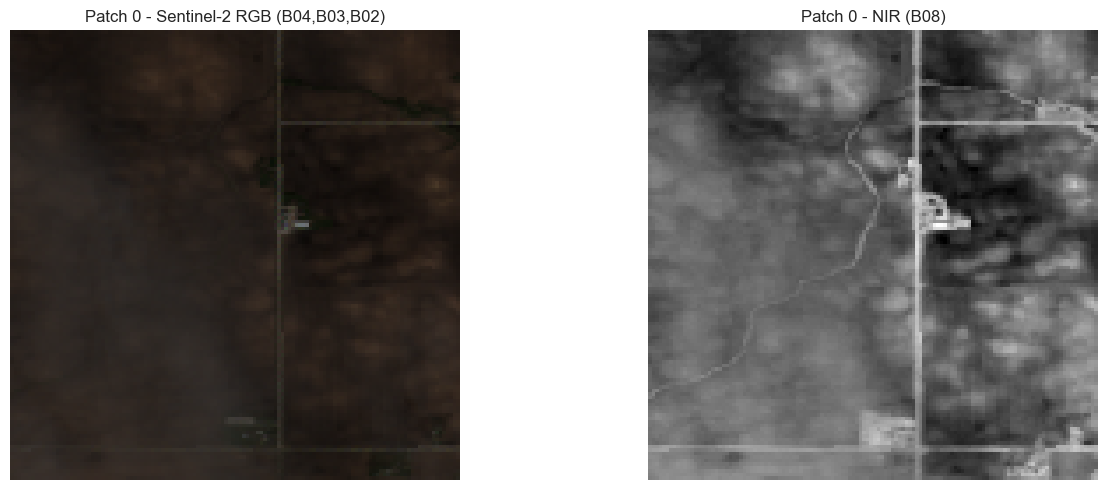

In [61]:
# Resumen de los parches descargados en memoria
print(f'Parches descargados en memoria: {len(all_data)}')

if len(all_data) == 0:
    raise RuntimeError(
        'No se descargaron parches de Sentinel-2 L2A. Verifica la celda de descarga y las credenciales de Sentinel Hub.'
    )


BAND_NAMES = [
    'B1 (Coastal Aerosol)', 'B2 (Blue)', 'B3 (Green)', 'B4 (Red)', 'B5 (RE1)', 'B6 (RE2)', 'B7 (RE3)', 'B8 (NIR)', 'B8A (NIR narrow)', 'B9 (Water Vapour)', 'B11 (SWIR 1)', 'B12 (SWIR 2)'
]
RGB_BANDS = [3, 2, 1]  # B04, B03, B02
NIR_BAND = 7  # B08


def normalize_patch_shape(patch: np.ndarray) -> np.ndarray:
    patch = np.asarray(patch)
    if patch.ndim == 3 and patch.shape[0] == 12:
        return patch
    if patch.ndim == 3 and patch.shape[-1] == 12:
        return np.moveaxis(patch, -1, 0)
    raise ValueError(f'Unexpected patch shape: {patch.shape}')


def scale_uint16_for_display(image: np.ndarray) -> np.ndarray:
    image = image.astype(np.float32)
    image = np.clip(image / 10000.0, 0, 1)
    return image

all_data_norm = [normalize_patch_shape(patch) for patch in all_data]
all_data_arr = np.stack(all_data_norm)

print('all_data_arr shape:', all_data_arr.shape)
print('dtype:', all_data_arr.dtype)
print('example patch min/max:', np.nanmin(all_data_arr), np.nanmax(all_data_arr))
print('patch dates:', patch_dates)

for idx, patch in enumerate(all_data_norm):
    print(f'Patch {idx}: shape={patch.shape}, dtype={patch.dtype}, min={patch.min():.3f}, max={patch.max():.3f}')

rgb = np.stack([scale_uint16_for_display(all_data_arr[0, b]) for b in RGB_BANDS], axis=-1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(rgb)
axes[0].set_title('Patch 0 - Sentinel-2 RGB (B04,B03,B02)')
axes[0].axis('off')
axes[1].imshow(scale_uint16_for_display(all_data_arr[0, NIR_BAND]), cmap='gray')
axes[1].set_title('Patch 0 - NIR (B08)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

### 1.1 Estructura esperada del dataset
- `data/Sentinel-2-L2A/B01-B12/` — archivos GeoTIFF o NumPy por escena
- `data/Sentinel-2-L2A/metadata/` — CSV, JSON o GeoJSON de fechas, tile, orbit, sensor, nubes, etc.
- `data/Sentinel-2-L2A/cloud_masks/` — máscaras QA60 o B09/B10-based para QA/QC.

## 2. Análisis de Estructura del Dataset
<a id="2-estructura"></a>

In [62]:
def print_dataset_structure(data: np.ndarray, dates: list[pd.Timestamp]):
    print('Número de parches:', data.shape[0])
    print('Bandas por parche:', data.shape[1])
    print('Dimensiones espaciales:', data.shape[2:])
    print('Fechas de los parches:', [date.strftime('%Y-%m-%d') for date in dates])
    print('Tipo de dato:', data.dtype)
    print('Valor mínimo/máximo global:', np.nanmin(data), np.nanmax(data))
    print('Rango de valores de reflectancia aproximado:', np.nanpercentile(data, 1), np.nanpercentile(data, 99))

print_dataset_structure(all_data_arr, patch_dates)


Número de parches: 3
Bandas por parche: 12
Dimensiones espaciales: (128, 128)
Fechas de los parches: ['2023-04-01', '2023-06-01', '2023-08-01']
Tipo de dato: uint16
Valor mínimo/máximo global: 71 15802
Rango de valores de reflectancia aproximado: 189.0 10500.0


In [63]:
def patch_info(patch: np.ndarray, date: pd.Timestamp | None = None):
    print('Patch', date.strftime('%Y-%m-%d') if date is not None else 'desconocida')
    print(f'  shape={patch.shape}')
    for idx in [0, 3, 7, 10]:
        band = patch[idx]
        print(
            f'  {BAND_NAMES[idx]} mean={np.nanmean(band):.3f}, '
            f'min/max={np.nanmin(band):.3f}/{np.nanmax(band):.3f}'
        )
    print(f'  % nodata (>=65535): {np.mean(patch >= 65535) * 100:.2f}%')

if all_data_norm:
    patch_info(all_data_norm[0], patch_dates[0] if patch_dates else None)

Patch 2023-04-01
  shape=(12, 128, 128)
  B1 (Coastal Aerosol) mean=973.794, min/max=438.000/1635.000
  B4 (Red) mean=1563.763, min/max=384.000/4152.000
  B8 (NIR) mean=2249.692, min/max=880.000/4512.000
  B11 (SWIR 1) mean=3780.448, min/max=2028.000/5716.000
  % nodata (>=65535): 0.00%


## 3. Análisis Univariante
<a id="3-univariante"></a>

,band,mean,std,min,max,p10,p50,p90,skew,kurtosis
0,B1 (Coastal Aerosol),1489.446,2252.347,222.0,12367.0,391.0,637.0,4261.0,2.783,6.968
1,B2 (Blue),1462.056,2179.275,103.0,12272.0,348.0,643.0,4176.0,2.738,6.799
2,B3 (Green),1569.617,2000.174,130.0,11536.0,501.0,835.0,4032.0,2.701,6.723
3,B4 (Red),1511.073,1959.601,71.0,11016.0,277.0,872.0,3764.0,2.489,6.015
4,B5 (RE1),1851.610,2012.895,154.0,11642.0,605.0,1207.5,4209.9,2.557,6.275
5,B6 (RE2),3160.590,1815.973,631.0,11199.0,1401.0,3148.0,5470.0,1.771,3.518
6,B7 (RE3),3958.756,2019.751,783.0,10972.0,1600.0,4102.0,6258.9,0.607,-0.075
7,B8 (NIR),4025.883,2005.123,808.0,11464.0,1736.0,4040.0,6424.0,0.759,0.328
8,B8A (NIR narrow),4198.998,1986.780,973.0,10822.0,1809.0,4407.0,6428.8,0.453,-0.423
9,B9 (Water Vapour),4823.301,3477.199,840.0,15802.0,1784.0,4414.0,9404.0,1.792,2.960


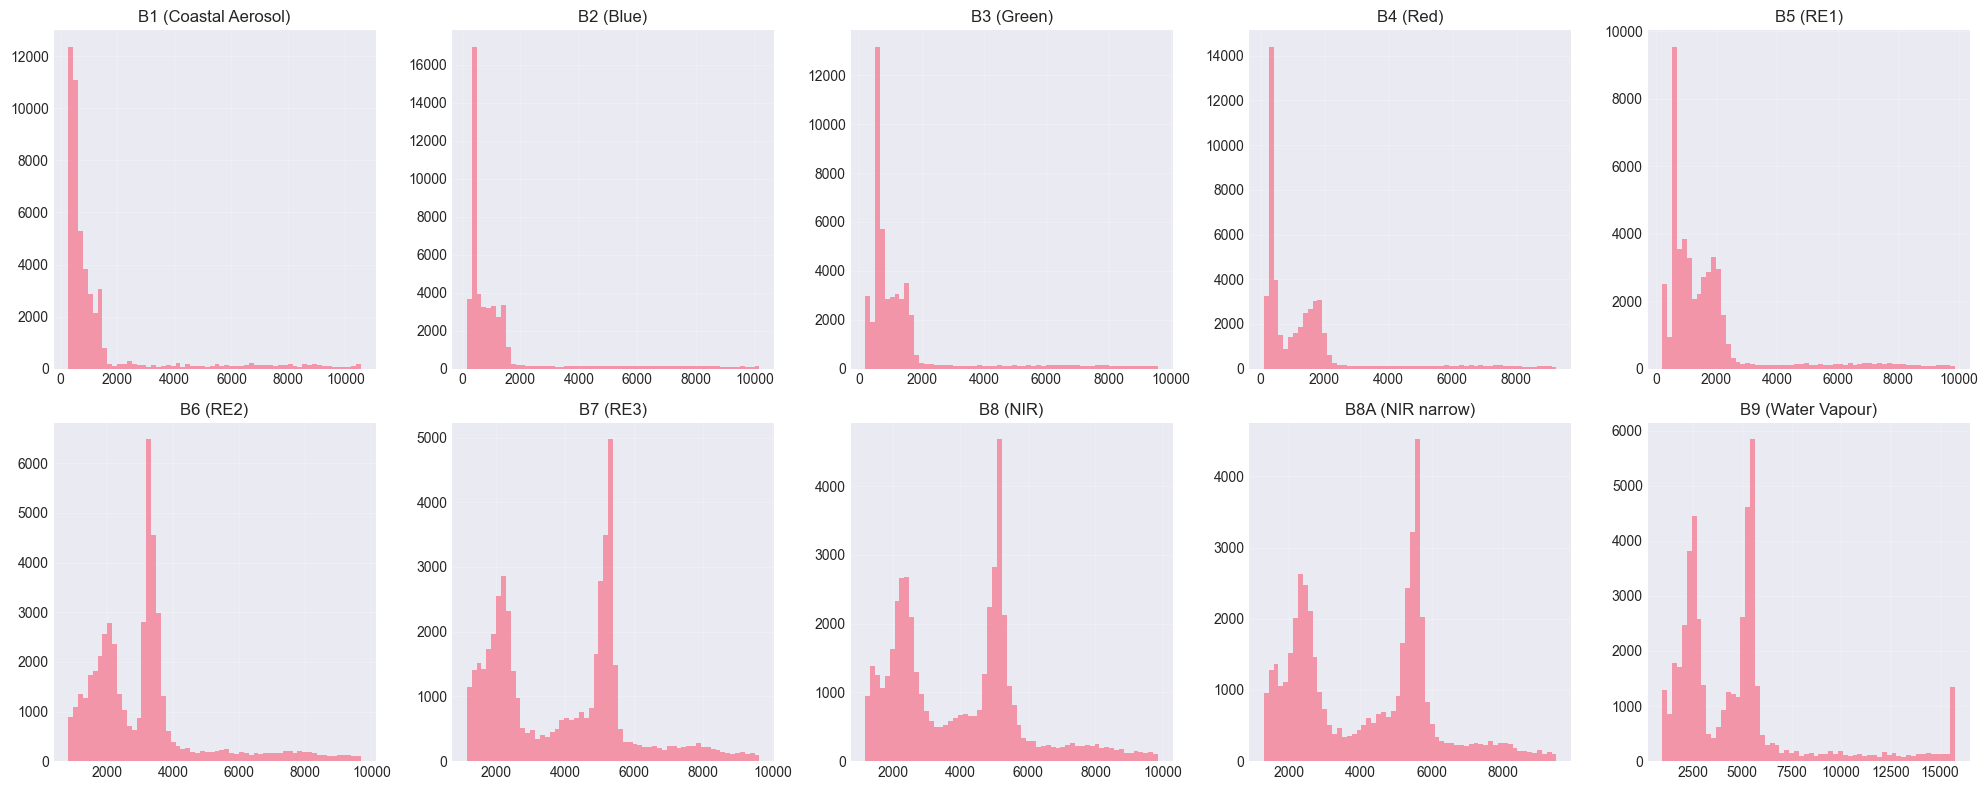

In [64]:
if len(all_data_arr) > 0:
    band_stats = []
    for idx, name in enumerate(BAND_NAMES):
        band = all_data_arr[:, idx]
        flat = band.flatten()[~np.isnan(band.flatten())]
        band_stats.append({
            'band': name,
            'mean': float(np.nanmean(band)),
            'std': float(np.nanstd(band)),
            'min': float(np.nanmin(band)),
            'max': float(np.nanmax(band)),
            'p10': float(np.nanpercentile(band, 10)),
            'p50': float(np.nanpercentile(band, 50)),
            'p90': float(np.nanpercentile(band, 90)),
            'skew': float(skew(flat)),
            'kurtosis': float(kurtosis(flat)),
        })

    stats = pd.DataFrame(band_stats)
    display(stats.round(3))

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for i, band_name in enumerate(BAND_NAMES[:10]):
        band_data = all_data_arr[:, i].flatten()
        filtered = band_data[(band_data > np.percentile(band_data, 1)) & (band_data < np.percentile(band_data, 99))]
        axes[i].hist(filtered, bins=60, alpha=0.7)
        axes[i].set_title(band_name)
        axes[i].grid(alpha=0.2)

    for ax in axes[len(BAND_NAMES[:10]):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [65]:
# Prueba adicional de forma de las distribuciones por banda
sample_s2 = all_data_arr
C = min(10, sample_s2.shape[1])

print("\n" + "="*80)
print("ANALISIS DE FORMA DE DISTRIBUCIONES")
print("="*80)
print(f"{'Banda':<20s} | {'Skewness':>10s} | {'Kurtosis':>10s} | {'Interpretacion'}")
print("-" * 80)

skewed_bands = []
for i, band_name in enumerate(BAND_NAMES[:C]):
    band_data = sample_s2[:, i, :, :].flatten()
    band_data = band_data[band_data > 0]

    sk = skew(band_data)
    kurt = kurtosis(band_data)

    if abs(sk) < 0.5:
        interpretation = "Aproximadamente simetrica"
    elif sk > 0:
        interpretation = "Sesgada derecha - transformacion recomendada"
        skewed_bands.append(band_name)
    else:
        interpretation = "Sesgada izquierda"
        skewed_bands.append(band_name)

    print(f"{band_name:<20s} | {sk:>10.2f} | {kurt:>10.2f} | {interpretation}")

print(f"\nBandas que requieren transformacion no lineal: {len(skewed_bands)}")
for band in skewed_bands:
    print(f"  - {band}")


ANALISIS DE FORMA DE DISTRIBUCIONES
Banda                |   Skewness |   Kurtosis | Interpretacion
--------------------------------------------------------------------------------
B1 (Coastal Aerosol) |       2.78 |       6.97 | Sesgada derecha - transformacion recomendada
B2 (Blue)            |       2.74 |       6.80 | Sesgada derecha - transformacion recomendada
B3 (Green)           |       2.70 |       6.72 | Sesgada derecha - transformacion recomendada
B4 (Red)             |       2.49 |       6.01 | Sesgada derecha - transformacion recomendada
B5 (RE1)             |       2.56 |       6.28 | Sesgada derecha - transformacion recomendada
B6 (RE2)             |       1.77 |       3.52 | Sesgada derecha - transformacion recomendada
B7 (RE3)             |       0.61 |      -0.08 | Sesgada derecha - transformacion recomendada
B8 (NIR)             |       0.76 |       0.33 | Sesgada derecha - transformacion recomendada
B8A (NIR narrow)     |       0.45 |      -0.42 | Aproximadamente s

## 4. Análisis Temporal
<a id="4-temporal"></a>

Este análisis asume que el dataset contiene escenas ordenadas por fecha. En caso de no existir una columna de metadatos, extraiga la fecha de los nombres de archivo.

,date,B04_mean,B08_mean,NDVI_mean,EVI_mean
0,2023-04-01,1563.762756,2249.691711,0.180789,0.513476
1,2023-06-01,409.274292,4645.346191,0.830960,2.827481
2,2023-08-01,2560.183350,5182.611145,0.538835,inf


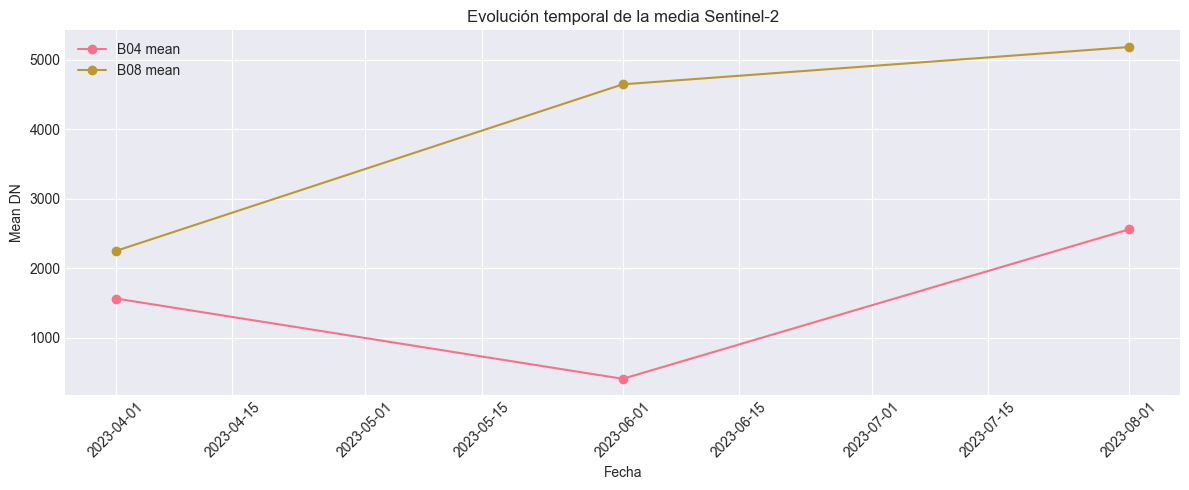

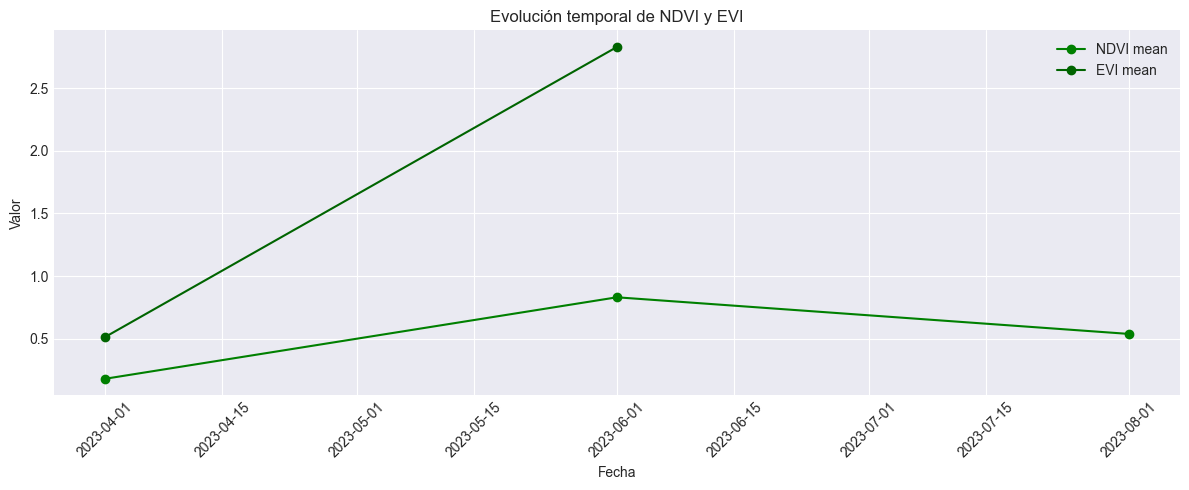

In [66]:
def calculate_index(nir: np.ndarray, red: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    return (nir - red) / (nir + red + eps)

if len(patch_dates) == len(all_data_arr) and len(patch_dates) > 0:
    df_times = pd.DataFrame({
        'date': patch_dates,
        'B04_mean': [float(np.nanmean(patch[3])) for patch in all_data_arr],
        'B08_mean': [float(np.nanmean(patch[7])) for patch in all_data_arr],
        'NDVI_mean': [float(np.nanmean(calculate_index(patch[7].astype(np.float32), patch[3].astype(np.float32)))) for patch in all_data_arr],
        'EVI_mean': [float(np.nanmean((2.5 * (patch[7].astype(np.float32) - patch[3].astype(np.float32))) / (patch[7].astype(np.float32) + 6 * patch[3].astype(np.float32) - 7.5 * patch[1].astype(np.float32) + 1))) for patch in all_data_arr],
    })
    df_times = df_times.sort_values('date')
    display(df_times)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_times['date'], df_times['B04_mean'], marker='o', label='B04 mean')
    ax.plot(df_times['date'], df_times['B08_mean'], marker='o', label='B08 mean')
    ax.set(title='Evolución temporal de la media Sentinel-2', xlabel='Fecha', ylabel='Mean DN')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df_times['date'], df_times['NDVI_mean'], marker='o', label='NDVI mean', color='green')
    ax.plot(df_times['date'], df_times['EVI_mean'], marker='o', label='EVI mean', color='darkgreen')
    ax.set(title='Evolución temporal de NDVI y EVI', xlabel='Fecha', ylabel='Valor')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No hay fechas de parche definidas para el análisis temporal.')


## 5. Análisis Bivariante/Multivariante
<a id="6-bivariante"></a>

Analiza la correlación espectral y la reducción de dimensionalidad con PCA para detectar redundancias.

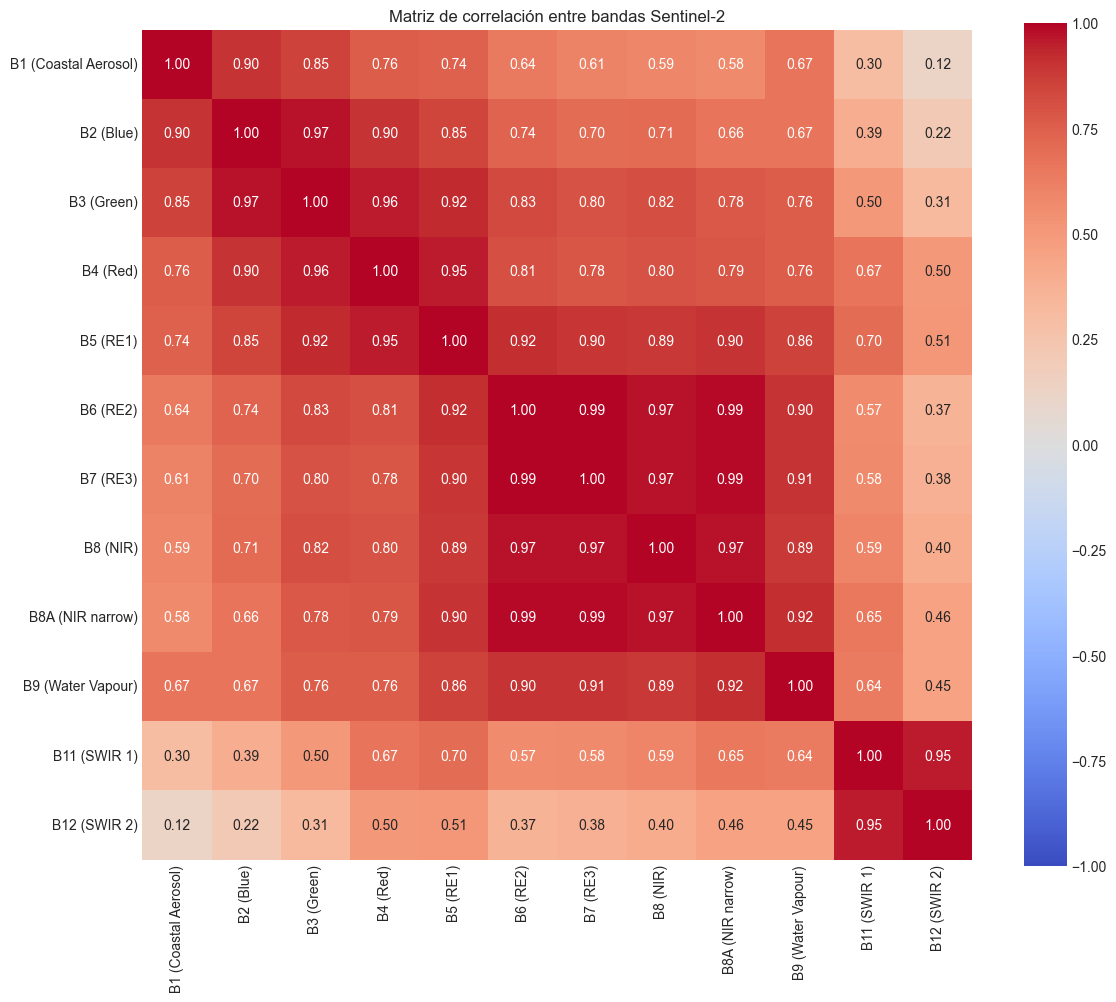

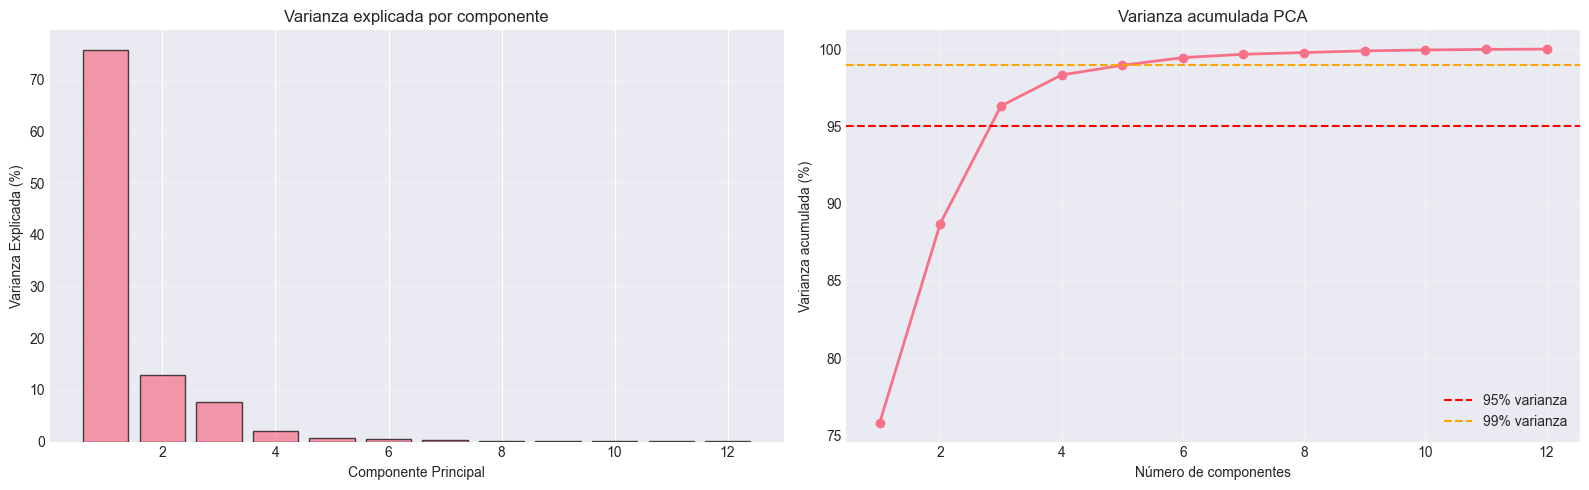

Componentes para 95% varianza: 3
Componentes para 99% varianza: 6


In [67]:
if len(all_data_arr) > 0:
    patch = all_data_arr[0].astype(np.float32)
    flattened = patch.reshape(patch.shape[0], -1).T
    df_bands = pd.DataFrame(flattened, columns=BAND_NAMES)

    corr_matrix = df_bands.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True)
    plt.title('Matriz de correlación entre bandas Sentinel-2')
    plt.tight_layout()
    plt.show()

    scaler = StandardScaler()
    sample_size = min(10000, len(df_bands))
    data_scaled = scaler.fit_transform(df_bands.sample(sample_size, random_state=RANDOM_SEED))
    pca = PCA()
    pca.fit(data_scaled)
    explained = np.cumsum(pca.explained_variance_ratio_) * 100
    n95 = np.argmax(explained >= 95) + 1
    n99 = np.argmax(explained >= 99) + 1

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_ * 100, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Componente Principal')
    axes[0].set_ylabel('Varianza Explicada (%)')
    axes[0].set_title('Varianza explicada por componente')
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].plot(range(1, len(explained) + 1), explained, marker='o', linewidth=2)
    axes[1].axhline(y=95, color='red', linestyle='--', label='95% varianza')
    axes[1].axhline(y=99, color='orange', linestyle='--', label='99% varianza')
    axes[1].set_xlabel('Número de componentes')
    axes[1].set_ylabel('Varianza acumulada (%)')
    axes[1].set_title('Varianza acumulada PCA')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Componentes para 95% varianza: {n95}')
    print(f'Componentes para 99% varianza: {n99}')
else:
    print('No hay datos suficientes para análisis multivariante.')


## 6. Detección de Valores Atípicos
<a id="7-outliers"></a>

Identifique valores atípicos en las bandas y use IQR para cuantificar el impacto en el dataset.

,band,Q1,Q3,IQR,lower,upper,n_outliers,pct_outliers
0,B1 (Coastal Aerosol),441.0,1198.0,757.0,-694.5,2333.5,6476,13.18
1,B2 (Blue),398.0,1296.0,898.0,-949.0,2643.0,6052,12.31
2,B3 (Green),566.0,1490.0,924.0,-820.0,2876.0,5801,11.80
3,B4 (Red),319.0,1748.0,1429.0,-1824.5,3891.5,4809,9.78
4,B5 (RE1),682.0,1963.0,1281.0,-1239.5,3884.5,5148,10.47
5,B6 (RE2),1955.0,3485.0,1530.0,-340.0,5780.0,4458,9.07
6,B7 (RE3),2139.0,5264.0,3125.0,-2548.5,9951.5,271,0.55
7,B8 (NIR),2306.0,5180.0,2874.0,-2005.0,9491.0,786,1.60
8,B8A (NIR narrow),2380.0,5568.0,3188.0,-2402.0,10350.0,50,0.10
9,B9 (Water Vapour),2425.0,5483.0,3058.0,-2162.0,10070.0,4485,9.12


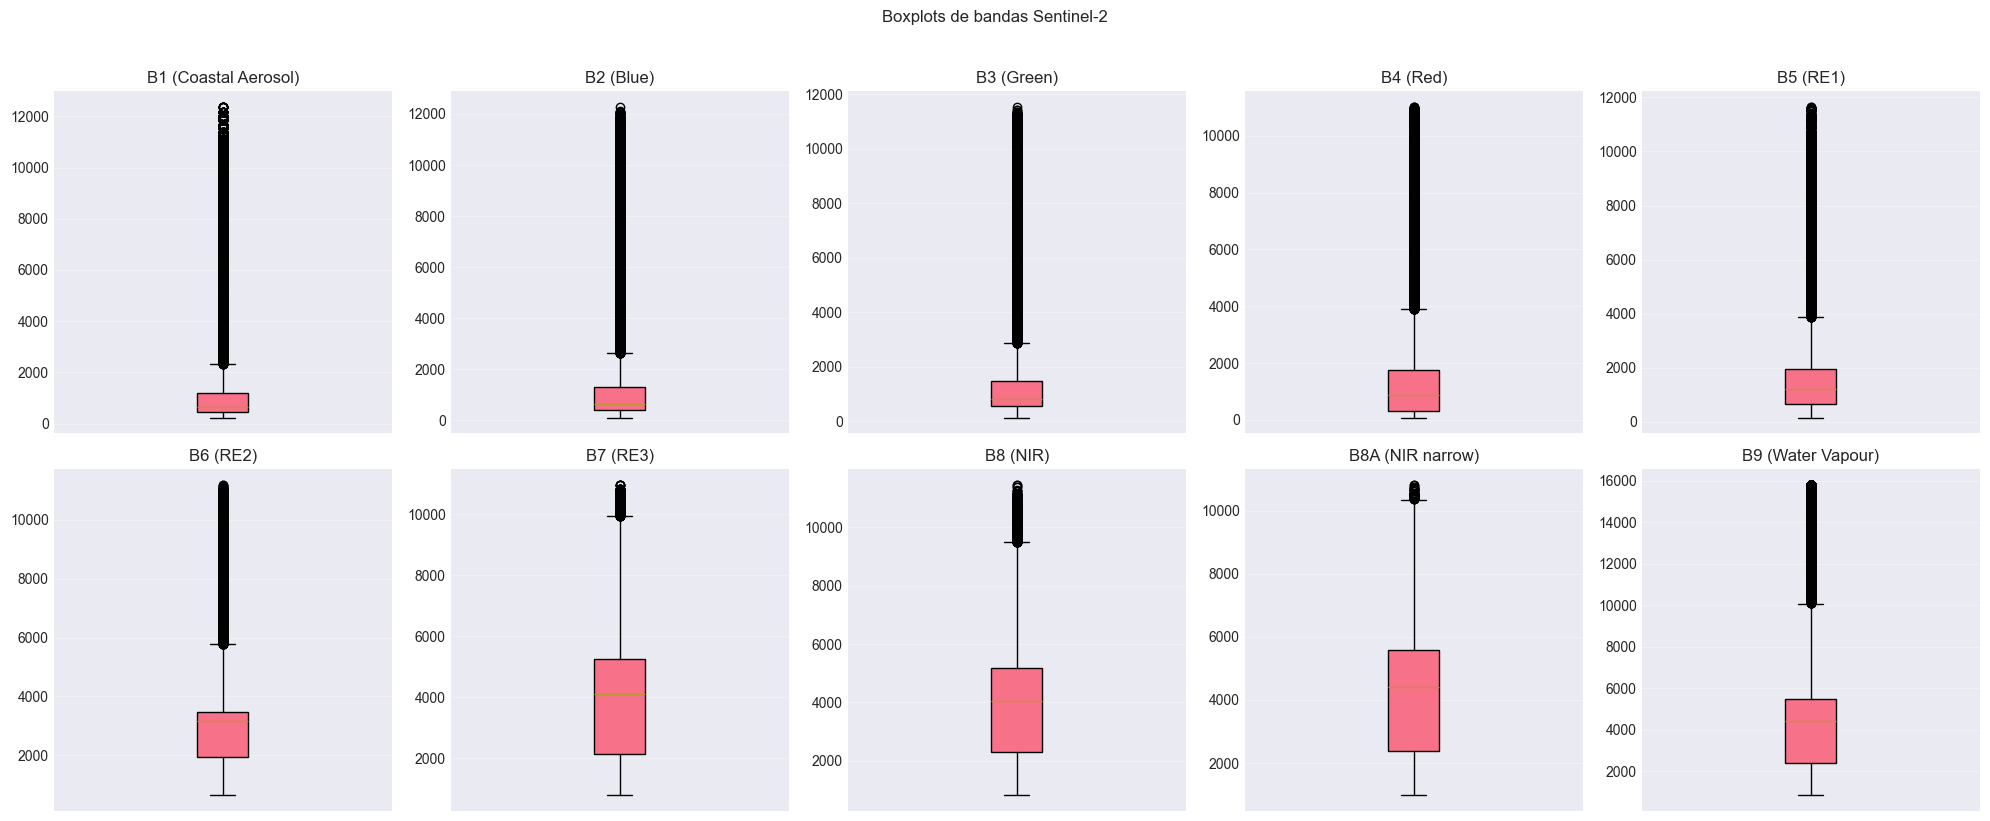

In [68]:
if len(all_data_arr) > 0:
    outlier_summary = []
    for idx, band_name in enumerate(BAND_NAMES[:10]):
        band_data = all_data_arr[:, idx].flatten()
        band_data = band_data[np.isfinite(band_data)]
        q1 = np.percentile(band_data, 25)
        q3 = np.percentile(band_data, 75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = ((band_data < lower) | (band_data > upper)).sum()
        outlier_summary.append({
            'band': band_name,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'lower': lower,
            'upper': upper,
            'n_outliers': int(outliers),
            'pct_outliers': float(outliers / band_data.size * 100),
        })

    df_outliers = pd.DataFrame(outlier_summary)
    display(df_outliers.round(2))

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for i, band_name in enumerate(BAND_NAMES[:10]):
        band_data = all_data_arr[:, i].flatten()
        band_data = band_data[np.isfinite(band_data)]
        axes[i].boxplot(band_data, vert=True, patch_artist=True)
        axes[i].set_title(band_name)
        axes[i].set_xticks([])
        axes[i].grid(True, alpha=0.3, axis='y')

    for ax in axes[len(BAND_NAMES[:10]):]:
        ax.axis('off')

    plt.suptitle('Boxplots de bandas Sentinel-2', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No hay datos suficientes para la detección de valores atípicos.')


## 7. Preprocesamiento Recomendado
<a id="7-preprocessing"></a>

- Normalización z-score por banda utilizando estadísticas de referencia.
- Manejo de valores atípicos con Winsorization o IQR en lugar de eliminación.
- Extracción de índices espectrales clave: NDVI, EVI, NDWI, BSI.
- Resampling y armonización de bandas a 10 m para B01/B09/B11/B12.
- Filtrado de nubes y QA60 antes del análisis temporal.
- Reducción dimensional con PCA si se detecta alta correlación entre bandas.

## 8. Conclusiones
<a id="8-conclusiones"></a>

- Resume los principales hallazgos del dataset.
- Indica si las 12 bandas Sentinel-2 L2A y los índices derivados son adecuados para la clasificación de cultivos.
- Describe las transformaciones necesarias antes de entrenar modelos.
- Propone el siguiente paso en la canalización: normalización, mask QC y PCA.